# Задание 3.2 - сверточные нейронные сети (CNNs) в PyTorch

Это упражнение мы буде выполнять в Google Colab - https://colab.research.google.com/  
Google Colab позволяет запускать код в notebook в облаке Google, где можно воспользоваться бесплатным GPU!  

Авторы курса благодарят компанию Google и надеятся, что праздник не закончится.

Туториал по настройке Google Colab:  
https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d  
(Keras инсталлировать не нужно, наш notebook сам установит PyTorch)


In [1]:
# Intstall PyTorch and download data
# !pip3 install torch torchvision

# !wget -c http://ufldl.stanford.edu/housenumbers/train_32x32.mat http://ufldl.stanford.edu/housenumbers/test_32x32.mat

In [2]:
from collections import namedtuple

import matplotlib.pyplot as plt
import numpy as np
import PIL
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
from torch.utils.data.sampler import SubsetRandomSampler

from torchvision import transforms

In [3]:
device = torch.device("cuda:0") # Let's make sure GPU is available!

# Загружаем данные

In [4]:
# First, lets load the dataset
data_train = dset.SVHN('./', 
                       transform=transforms.Compose([
                           transforms.ToTensor(),
                           transforms.Normalize(mean=[0.43,0.44,0.47],
                                               std=[0.20,0.20,0.20])                           
                       ])
                      )
data_test = dset.SVHN('./', split='test', transform=transforms.Compose([
                           transforms.ToTensor(),
                           transforms.Normalize(mean=[0.43,0.44,0.47],
                                               std=[0.20,0.20,0.20])                           
                       ]))

Разделяем данные на training и validation.

На всякий случай для подробностей - https://pytorch.org/tutorials/beginner/data_loading_tutorial.html

In [5]:
batch_size = 64
NUM_WORKERS = 10

data_size = data_train.data.shape[0]
validation_split = .2
split = int(np.floor(validation_split * data_size))
indices = list(range(data_size))
np.random.shuffle(indices)

train_indices, val_indices = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_indices)
val_sampler = SubsetRandomSampler(val_indices)

train_loader = torch.utils.data.DataLoader(data_train, batch_size=batch_size, 
                                           sampler=train_sampler, num_workers=NUM_WORKERS)
val_loader = torch.utils.data.DataLoader(data_train, batch_size=batch_size,
                                         sampler=val_sampler, num_workers=NUM_WORKERS)

In [6]:
# We'll use a special helper module to shape it into a flat tensor
class Flattener(nn.Module):
    def forward(self, x):
        batch_size, *_ = x.shape
        return x.view(batch_size, -1)

Создадим простейшую сеть с новыми слоями:  
Convolutional - `nn.Conv2d`  
MaxPool - `nn.MaxPool2d`

In [7]:
nn_model = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(4),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(4),    
            Flattener(),
            nn.Linear(64*2*2, 10),
          )

nn_model.type(torch.cuda.FloatTensor)
nn_model.to(device)

loss = nn.CrossEntropyLoss().type(torch.cuda.FloatTensor)
optimizer = optim.SGD(nn_model.parameters(), lr=1e-1, weight_decay=1e-4)

Восстановите функцию `compute_accuracy` из прошлого задания.  
Единственное отличие в новом - она должна передать данные на GPU прежде чем прогонять через модель. Сделайте это так же, как это делает функция `train_model`

In [8]:
import copy
import torch

def train_model(
    model,
    train_loader,
    val_loader,
    loss,
    optimizer,
    num_epochs,
    scheduler=None,
    early_stopping=False,
    patience=5,
    min_delta=0.0
):
    loss_history = []
    train_history = []
    val_history = []

    best_val_acc = float("-inf")
    best_model_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        model.train()

        loss_accum = 0.0
        correct_samples = 0
        total_samples = 0

        for i_step, (x, y) in enumerate(train_loader):
            x_gpu = x.to(device)
            y_gpu = y.to(device)

            optimizer.zero_grad()

            prediction = model(x_gpu)
            loss_value = loss(prediction, y_gpu)

            loss_value.backward()
            optimizer.step()

            loss_accum += loss_value.item()

            predicted_classes = prediction.argmax(dim=1)
            correct_samples += (predicted_classes == y_gpu).sum().item()
            total_samples += y_gpu.size(0)

        train_loss = loss_accum / len(train_loader)
        train_acc = correct_samples / total_samples
        val_acc = compute_accuracy(model, val_loader)

        loss_history.append(train_loss)
        train_history.append(train_acc)
        val_history.append(val_acc)

        if scheduler is not None:
            scheduler.step()

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"loss = {train_loss:.4f} | "
            f"train_acc = {train_acc:.4f} | "
            f"val_acc = {val_acc:.4f}"
        )

        # Early stopping logic
        if val_acc > best_val_acc + min_delta:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if early_stopping and epochs_without_improvement >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break

    # Возвращаем лучшие веса по validation
    model.load_state_dict(best_model_state)

    return loss_history, train_history, val_history

@torch.no_grad()
def compute_accuracy(model, loader):
    """
    Computes accuracy on the dataset wrapped in a loader
    
    Returns: accuracy as a float value between 0 and 1
    """
    model.eval() # Evaluation mode

    total_samples = 0
    total_correct = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)

        total_samples += labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()


    return total_correct / total_samples

loss_history, train_history, val_history = train_model(nn_model, train_loader, val_loader, loss, optimizer, 5)

Epoch 1/5 | loss = 1.4068 | train_acc = 0.5292 | val_acc = 0.7553
Epoch 2/5 | loss = 0.6989 | train_acc = 0.7876 | val_acc = 0.7937
Epoch 3/5 | loss = 0.5870 | train_acc = 0.8235 | val_acc = 0.8065
Epoch 4/5 | loss = 0.5358 | train_acc = 0.8402 | val_acc = 0.8354
Epoch 5/5 | loss = 0.4996 | train_acc = 0.8533 | val_acc = 0.8404


# Аугментация данных (Data augmentation)

В работе с изображениями одним из особенно важных методов является аугментация данных - то есть, генерация дополнительных данных для тренировки на основе изначальных.   
Таким образом, мы получаем возможность "увеличить" набор данных для тренировки, что ведет к лучшей работе сети.
Важно, чтобы аугментированные данные были похожи на те, которые могут встретиться в реальной жизни, иначе польза от аугментаций уменьшается и может ухудшить работу сети.

С PyTorch идут несколько таких алгоритмов, называемых `transforms`. Более подробно про них можно прочитать тут -
https://pytorch.org/tutorials/beginner/data_loading_tutorial.html#transforms

Ниже мы используем следующие алгоритмы генерации:
- ColorJitter - случайное изменение цвета
- RandomHorizontalFlip - горизонтальное отражение с вероятностью 50%
- RandomVerticalFlip - вертикальное отражение с вероятностью 50%
- RandomRotation - случайный поворот

In [9]:
tfs = transforms.Compose([
    transforms.ColorJitter(hue=.50, saturation=.50),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(50, interpolation=PIL.Image.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.43,0.44,0.47],
                       std=[0.20,0.20,0.20])                           
])

# Create augmented train dataset
data_aug_train = dset.SVHN('./', 
                       transform=tfs
                      )

train_aug_loader = torch.utils.data.DataLoader(data_aug_train, batch_size=batch_size, 
                                           sampler=train_sampler)

Визуализируем результаты агментации (вообще, смотреть на сгенерированные данные всегда очень полезно).

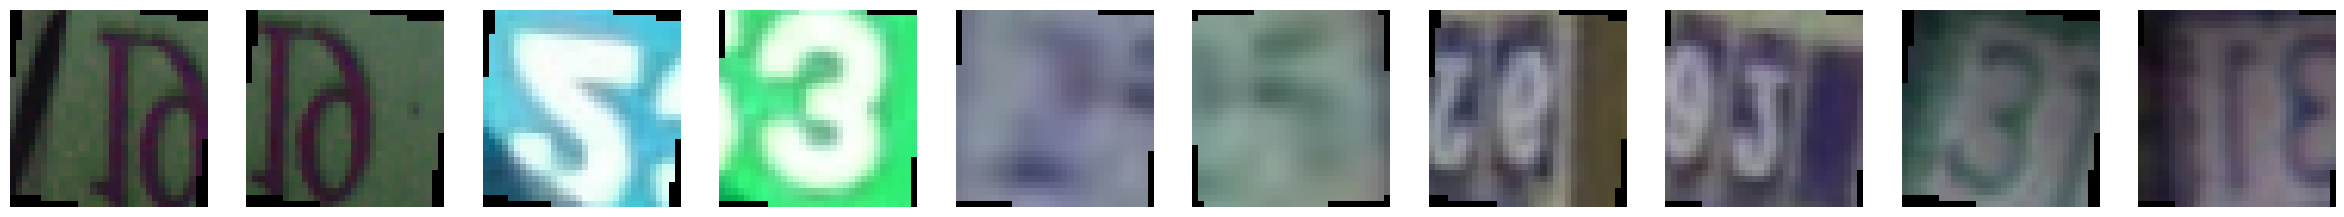

In [10]:
# Based on the visualizations, should we keep all the augmentations?

tfs = transforms.Compose([
    transforms.ColorJitter(hue=.20, saturation=.20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10, interpolation=PIL.Image.BILINEAR),
])

data_aug_vis = dset.SVHN('./', 
                       transform=tfs
                      )

plt.figure(figsize=(30, 3))

for i, (x, y) in enumerate(data_aug_vis):
    if i == 10:
        break
    plt.subplot(1, 10, i+1)
    plt.grid(False)
    plt.imshow(x)
    plt.axis('off')

Все ли агментации одинаково полезны на этом наборе данных? Могут ли быть среди них те, которые собьют модель с толку?

Выберите из них только корректные

In [11]:
tfs = transforms.Compose([
    transforms.ColorJitter(hue=.20, saturation=.20),
    transforms.RandomRotation(10, interpolation=PIL.Image.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.43,0.44,0.47],
                       std=[0.20,0.20,0.20])                           
])

train_aug_loader = torch.utils.data.DataLoader(data_train, batch_size=batch_size, sampler=train_sampler)

In [12]:
# Finally, let's train with augmentations!

# Note we shouldn't use augmentations on validation

loss_history, train_history, val_history = train_model(nn_model, train_aug_loader, val_loader, loss, optimizer, 5)

Epoch 1/5 | loss = 0.4761 | train_acc = 0.8590 | val_acc = 0.8545
Epoch 2/5 | loss = 0.4584 | train_acc = 0.8636 | val_acc = 0.8481
Epoch 3/5 | loss = 0.4405 | train_acc = 0.8707 | val_acc = 0.8324
Epoch 4/5 | loss = 0.4247 | train_acc = 0.8739 | val_acc = 0.8399
Epoch 5/5 | loss = 0.4122 | train_acc = 0.8770 | val_acc = 0.8615


# LeNet
Попробуем имплементировать классическую архитектуру сверточной нейронной сети, предложенную Яном ЛеКуном в 1998 году. В свое время она достигла впечатляющих результатов на MNIST, посмотрим как она справится с SVHN?
Она описана в статье ["Gradient Based Learning Applied to Document Recognition"](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf), попробуйте прочитать ключевые части и имплементировать предложенную архитетуру на PyTorch.

Реализовывать слои и функцию ошибки LeNet, которых нет в PyTorch, **не нужно** - просто возьмите их размеры и переведите в уже известные нам Convolutional, Pooling и Fully Connected layers.

Если в статье не очень понятно, можно просто погуглить LeNet и разобраться в деталях :)

In [13]:
# TODO: Implement LeNet-like architecture for SVHN task
lenet_model = nn.Sequential(
            nn.Conv2d(3, 6, 5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(6, 16, 5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            Flattener(),
            nn.Linear(16*5*5, 120),
            nn.ReLU(inplace=True),
            nn.Linear(120, 84),
            nn.ReLU(inplace=True),
            nn.Linear(84, 10)
          )

lenet_model.type(torch.cuda.FloatTensor)
lenet_model.to(device)

loss = nn.CrossEntropyLoss().type(torch.cuda.FloatTensor)
optimizer = optim.SGD(lenet_model.parameters(), lr=1e-1, weight_decay=1e-4)

In [14]:
# Let's train it!
loss_history, train_history, val_history = train_model(lenet_model, train_aug_loader, val_loader, loss, optimizer, 10)

Epoch 1/10 | loss = 1.2522 | train_acc = 0.5829 | val_acc = 0.8019
Epoch 2/10 | loss = 0.5116 | train_acc = 0.8481 | val_acc = 0.8539
Epoch 3/10 | loss = 0.4174 | train_acc = 0.8768 | val_acc = 0.8781
Epoch 4/10 | loss = 0.3622 | train_acc = 0.8932 | val_acc = 0.8776
Epoch 5/10 | loss = 0.3292 | train_acc = 0.9020 | val_acc = 0.8913
Epoch 6/10 | loss = 0.2982 | train_acc = 0.9108 | val_acc = 0.8860
Epoch 7/10 | loss = 0.2734 | train_acc = 0.9185 | val_acc = 0.8833
Epoch 8/10 | loss = 0.2558 | train_acc = 0.9232 | val_acc = 0.8917
Epoch 9/10 | loss = 0.2346 | train_acc = 0.9289 | val_acc = 0.8928
Epoch 10/10 | loss = 0.2195 | train_acc = 0.9337 | val_acc = 0.8579


# Подбор гиперпараметров

In [15]:
import copy
from itertools import product

# The key hyperparameters we're going to tune are learning speed, annealing rate and regularization
# We also encourage you to try different optimizers as well

Hyperparams = namedtuple("Hyperparams", ['learning_rate', 'anneal_epochs', 'reg', 'opt_name'])
RunResult = namedtuple("RunResult", ['model', 'train_history', 'val_history', 'final_val_accuracy'])


learning_rates = [1e-2, 1e-3, 1e-4]
anneal_coeff = 0.2
anneal_epochs = [1, 5, 10]
regs = [1e-3, 1e-4, 1e-5]
OPTIMIZERS = {
    "sgd": optim.SGD,
    "adam": optim.Adam
}

early_stopping = True
patience = 3
min_delta = 1e-4

batch_size = 64
epoch_num = 10

# Record all the runs here
# Key should be Hyperparams and values should be RunResult
run_record = {} 

# Use grid search or random search and record all runs in run_record dictionnary 
# Important: perform search in logarithmic space!

# TODO: Your code here!

def lenet():
    return nn.Sequential(
            nn.Conv2d(3, 6, 5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(6, 16, 5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            Flattener(),
            nn.Linear(16*5*5, 120),
            nn.ReLU(inplace=True),
            nn.Linear(120, 84),
            nn.ReLU(inplace=True),
            nn.Linear(84, 10)
          )

best_hp = None
best_val_acc = float("-inf")
best_model_state = None

for lr, ae, reg, opt_name in product(learning_rates, anneal_epochs, regs, OPTIMIZERS.keys()):
    hp = Hyperparams(lr, ae, reg, opt_name)
    print(hp)

    model = lenet().to(device)

    optimizer = OPTIMIZERS[opt_name](
        model.parameters(),
        lr=hp.learning_rate,
        weight_decay=hp.reg
    )
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda epoch, ae=ae: min(1.0, epoch / ae)
    )

    loss_history, train_history, val_history = train_model(
        model, 
        train_aug_loader, 
        val_loader, 
        loss, 
        optimizer, 
        epoch_num, 
        scheduler=scheduler,
        early_stopping=early_stopping,
        patience=patience,
        min_delta=min_delta
    )

    run_best_val_acc = max(val_history)

    run_record[hp] = RunResult(
        model=copy.deepcopy(model),
        train_history=train_history,
        val_history=val_history,
        final_val_accuracy=run_best_val_acc
    )

    if run_best_val_acc > best_val_acc:
        best_val_acc = run_best_val_acc
        best_hp = hp
        best_model_state = copy.deepcopy(model.state_dict())


print("Best hyperparameters:", best_hp)
print("Best val accuracy:", best_val_acc)

best_model = lenet()
best_model.load_state_dict(best_model_state)

Hyperparams(learning_rate=0.01, anneal_epochs=1, reg=0.001, opt_name='sgd')
Epoch 1/10 | loss = 2.3113 | train_acc = 0.0687 | val_acc = 0.0692
Epoch 2/10 | loss = 2.2490 | train_acc = 0.1779 | val_acc = 0.1856
Epoch 3/10 | loss = 2.1990 | train_acc = 0.2022 | val_acc = 0.2370
Epoch 4/10 | loss = 1.5682 | train_acc = 0.4846 | val_acc = 0.6116
Epoch 5/10 | loss = 0.8797 | train_acc = 0.7389 | val_acc = 0.7595
Epoch 6/10 | loss = 0.6871 | train_acc = 0.8008 | val_acc = 0.8077
Epoch 7/10 | loss = 0.5980 | train_acc = 0.8293 | val_acc = 0.8380
Epoch 8/10 | loss = 0.5392 | train_acc = 0.8453 | val_acc = 0.8440
Epoch 9/10 | loss = 0.4963 | train_acc = 0.8580 | val_acc = 0.8555
Epoch 10/10 | loss = 0.4647 | train_acc = 0.8675 | val_acc = 0.8563
Hyperparams(learning_rate=0.01, anneal_epochs=1, reg=0.001, opt_name='adam')
Epoch 1/10 | loss = 2.2892 | train_acc = 0.1421 | val_acc = 0.1445
Epoch 2/10 | loss = 2.2389 | train_acc = 0.1892 | val_acc = 0.1856
Epoch 3/10 | loss = 2.2366 | train_acc = 0

<All keys matched successfully>

In [17]:
test_loader = torch.utils.data.DataLoader(
    data_test,
    batch_size=batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS
)

best_model.to(device)
final_test_accuracy = compute_accuracy(best_model, test_loader)

print("Final test accuracy - ", final_test_accuracy)

Final test accuracy -  0.884181007990166


# Свободное упражнение - догоним и перегоним LeNet!

Попробуйте найти архитектуру и настройки тренировки, чтобы выступить лучше наших бейзлайнов.

Что можно и нужно попробовать:
- BatchNormalization (для convolution layers он в PyTorch называется [batchnorm2d](https://pytorch.org/docs/stable/nn.html#batchnorm2d))
- Изменить количество слоев и их толщину
- Изменять количество эпох тренировки
- Попробовать и другие агментации

In [19]:
my_model = nn.Sequential(
            nn.Conv2d(3, 16, 5),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, 5),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 5),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 5),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 10)
          )

my_model.type(torch.cuda.FloatTensor)
my_model.to(device)


tfs = transforms.Compose([
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomRotation(10, interpolation=PIL.Image.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.43,0.44,0.47],
                       std=[0.20,0.20,0.20])                           
])

train_aug_loader = torch.utils.data.DataLoader(data_train, batch_size=batch_size, sampler=train_sampler)


LR = 1e-3
REG = 1e-4
ANNEALING_EPOCHS = 1

EPOCHS = 10

loss = nn.CrossEntropyLoss().type(torch.cuda.FloatTensor)
optimizer = optim.Adam(my_model.parameters(), lr=LR, weight_decay=REG)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda epoch, ae=ANNEALING_EPOCHS: min(1.0, epoch / ae)
)

loss_history, train_history, val_history = train_model(my_model, train_aug_loader, val_loader, loss, optimizer, EPOCHS, scheduler=scheduler)

Epoch 1/10 | loss = 2.4295 | train_acc = 0.0800 | val_acc = 0.0806
Epoch 2/10 | loss = 0.5935 | train_acc = 0.8231 | val_acc = 0.8894
Epoch 3/10 | loss = 0.3296 | train_acc = 0.9013 | val_acc = 0.9031
Epoch 4/10 | loss = 0.2795 | train_acc = 0.9162 | val_acc = 0.9145
Epoch 5/10 | loss = 0.2536 | train_acc = 0.9254 | val_acc = 0.9232
Epoch 6/10 | loss = 0.2309 | train_acc = 0.9311 | val_acc = 0.9253
Epoch 7/10 | loss = 0.2117 | train_acc = 0.9380 | val_acc = 0.9271
Epoch 8/10 | loss = 0.1971 | train_acc = 0.9411 | val_acc = 0.9311
Epoch 9/10 | loss = 0.1835 | train_acc = 0.9458 | val_acc = 0.9294
Epoch 10/10 | loss = 0.1719 | train_acc = 0.9498 | val_acc = 0.9289


# Финальный аккорд - проверим лучшую модель на test set

В качестве разнообразия - напишите код для прогона модели на test set вы.

В результате вы должны натренировать модель, которая покажет более **90%** точности на test set.  
Как водится, лучший результат в группе получит дополнительные баллы!

In [20]:
test_loader = torch.utils.data.DataLoader(
    data_test,
    batch_size=batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS
)

final_test_accuracy = compute_accuracy(my_model, test_loader)

print("Final test accuracy - ", final_test_accuracy)

Final test accuracy -  0.9301628764597418
